## Useful functions

You don't need to change these functions, and you don't have to necessarilty use them to complete your assignment.

In [153]:
import numpy as np
from IPython.display import display
from IPython.display import Markdown
from fasttext_pybind import f1score
from sklearn.neighbors import LocalOutlierFactor


def report(string):
    display(Markdown(string))

class Table:
    def header(self, *fields):
        self.doc = "|"
        for field in fields:
            self.doc += f" {field} |"
        self.doc += "\n"
        self.doc += "|"
        for field in fields:
            self.doc += " --- |"
        self.doc += "\n"
        return self

    def __init__(self):
        self.doc = ""

    def row(self, *values):
        self.doc += "|"
        for value in values:
            self.doc += f" {value} |"
        self.doc += "\n"
        return self

    def report(self):
        report(self.doc)

def start_table():
    table = Table()
    table.header("Model", "Recall", "Precision", "F1 Score", "Correct", "Missed", "False Positives")
    return table


enable_debug = False

def debug(string):
    if (enable_debug):
        print(string)

def sinTransform(val, period) :
    return np.sin(2*np.pi*val/period)

def cosTransform(val, period) :
    return np.cos(2*np.pi*val/period)


def sin_cos_transform(columnName, dataFrame):
    period = dataFrame[columnName].nunique()
    dataFrame[columnName + '_sin'] = dataFrame[columnName].map(lambda val: sinTransform(val, period))
    dataFrame[columnName + '_cos'] = dataFrame[columnName].map(lambda val: cosTransform(val, period))

# https://xkcd.com/221/ - 4 is overused
random_seed = 221

In [154]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, f1_score

# plot one or more features (using separate plots) for a start and end date, if y is set then it shows the anomalies
#  (could be predicted or real if ground truth used)
def plot_features(df, start_day, start_year, end_day, end_year, features, y=None):
    # Filter the period
    mask = (
        (df['year'] > start_year) |
        ((df['year'] == start_year) & (df['day_of_year'] >= start_day))
    ) & (
        (df['year'] < end_year) |
        ((df['year'] == end_year) & (df['day_of_year'] <= end_day))
    )
    df_period = df[mask].copy()
    df_period = df_period.reset_index(drop=False)  # Keep original indices for mapping y
    df_period['date'] = pd.to_datetime(
        df_period['year'].astype(int).astype(str) + df_period['day_of_year'].astype(int).astype(str).str.zfill(3), format='%Y%j')

    if isinstance(features, str):
        features = [features]

    for feature in features:
        plt.figure(figsize=(10, 4))
        plt.plot(df_period['date'], df_period[feature], marker='o', linestyle='-')

        # If y is provided, plot anomalies
        if y is not None:
            anomaly_indices = df_period[df_period['index'].map(lambda idx: y[idx] == -1)].index
            plt.scatter(
                df_period.loc[anomaly_indices, 'date'],
                df_period.loc[anomaly_indices, feature],
                color='red', marker='x', s=100, label='Anomaly'
            )
            plt.legend()

        plt.title(f'{feature} over time')
        plt.xlabel('Date')
        plt.ylabel(feature)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# show a summary of the dataset, not crucial, but useful to understand the data
def print_summary(y_true):
    total = len(y_true)
    n_anomalies = (y_true == -1).sum()
    n_normals = (y_true == 1).sum()

    print("Dataset Summary:")
    print(f"Total instances:         {total}")
    print(f"Normal instances (1):    {n_normals}")
    print(f"Anomalous instances (-1): {n_anomalies}")
    print(f"Anomaly ratio:           {n_anomalies / total:.3%}")

# plot detections, useful when you already have the predictions and want to observe then on the data for each feature
def plot_detection(df, y_true, y_pred, start_day, start_year, end_day, end_year, feature):
    mask = (
        (df['year'] > start_year) |
        ((df['year'] == start_year) & (df['day_of_year'] >= start_day))
    ) & (
        (df['year'] < end_year) |
        ((df['year'] == end_year) & (df['day_of_year'] <= end_day))
    )
    df_period = df[mask].copy()
    idx_period = df_period.index
    df_period['date'] = pd.to_datetime(
    df_period['year'].astype(int).astype(str) + df_period['day_of_year'].astype(int).astype(str).str.zfill(3), format='%Y%j')
    y_true_period = y_true[idx_period]
    y_pred_period = y_pred[idx_period]

    correct = (y_true_period == -1) &  (y_pred_period == -1)
    missed = (y_true_period == -1) & (y_pred_period != -1)
    false_pos = (y_true_period != -1) & (y_pred_period == -1)

    plt.figure(figsize=(10, 4))
    plt.plot(df_period['date'], df_period[feature], label=feature, color='blue', linestyle='-')
    plt.scatter(df_period.loc[correct, 'date'], df_period.loc[correct, feature],
                marker='x', color='green', label='Correct Anomaly')
    plt.scatter(df_period.loc[missed, 'date'], df_period.loc[missed, feature],
                marker='x', color='red', label='Missed Anomaly')
    plt.scatter(df_period.loc[false_pos, 'date'], df_period.loc[false_pos, feature],
                marker='x', color='orange', label='False Positive')

    plt.title(f'{feature} with Detected Anomalies')
    plt.xlabel('Date')
    plt.ylabel(feature)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# to facilitate the visualization of the results for the anomaly detection methods in part 1
def evaluate_predictions(y_true, y_pred, model_name="unnamed", header=True, table=None):
    # convert from -1 to 1 (1 for anomaly, 0 for normal) for evaluating
    y_true_binary = (y_true == -1).astype(int)
    y_pred_binary = (y_pred == -1).astype(int)

    recall = recall_score(y_true_binary, y_pred_binary)
    precision = precision_score(y_true_binary, y_pred_binary)
    f1score = f1_score(y_true_binary, y_pred_binary)

    correct = (y_true == -1) & (y_pred == -1)
    missed = (y_true == -1) & (y_pred != -1)
    false_positives = (y_true != -1) & (y_pred == -1)

    if header:
        table.header("Model", "Recall", "Precision", "F1 Score", "Correct", "Missed", "False Positives")
    table.row(model_name, f"{recall:.3f}", f"{precision:.3f}", f"{f1score:.3f}", correct.sum(), missed.sum(), false_positives.sum())

## Example: reading and visualizing the data

In [155]:
import os
import pandas as pd

# Loading the data. y2122 contains the 'labels'
df2122 = None
y2122 = None

# Check and load if files exist
if os.path.exists("GenSyn2122.csv") and os.path.exists("GenSyn_labels2122.csv"):
    print("Loading GenSyn2122 dataset...")
    df2122 = pd.read_csv("GenSyn2122.csv")
    # -1 = anomaly, 1 = normal
    y2122 = pd.read_csv("GenSyn_labels2122.csv")['anomaly_label'].values

# Visualise part of the data...
# plot_features(df2122, 1, 2021, 100, 2021, ['temperature','energy_usage', 'season'])
display(df2122)

Loading GenSyn2122 dataset...


,year,day_of_year,season,temperature,humidity,energy_usage
0,2021,1,summer,19.708638,78.625889,11.731837
1,2021,2,summer,20.703554,78.350411,13.453957
2,2021,3,summer,21.339178,82.736788,15.393096
3,2021,4,summer,20.823304,79.921728,16.657684
4,2021,5,summer,22.277698,80.406175,16.927320
...,...,...,...,...,...,...
725,2022,361,summer,24.648768,79.422802,18.579817
726,2022,362,summer,24.362897,80.541095,19.394421
727,2022,363,summer,24.730546,85.748327,20.060006
728,2022,364,summer,26.975549,81.506959,20.840548


### Example: Using function evaluate_predictions

In [156]:
# evaluate_predictions(y_true=y2122, y_pred=the predictions of your model, model_name="name of the model", header=True):
# for example, if we use the ground truth to evaluate. You can past the result on a markdown cell to get a nice looking table
iso_table = Table()
evaluate_predictions(y_true=y2122, y_pred=y2122, model_name="example", header=True, table=iso_table)

iso_table.report()

| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| example | 1.000 | 1.000 | 1.000 | 18 | 0 | 0 |


### Example: plotting anomalies using plot_detection

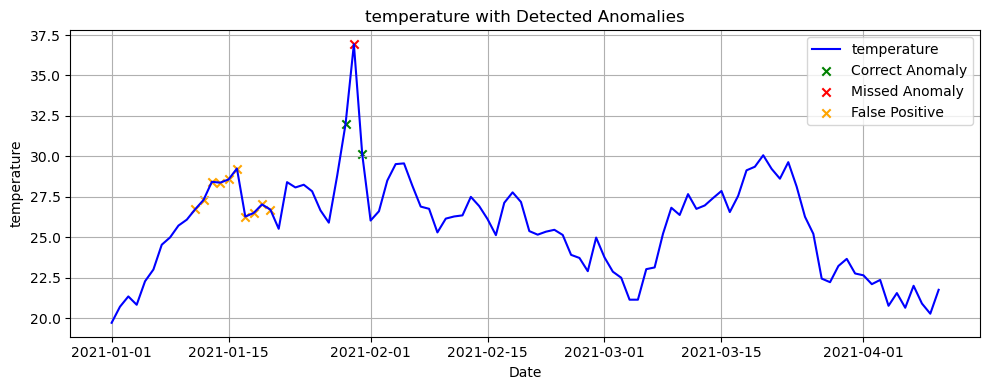

In [157]:
# generating some fake predictions for the plot
fake_preds=y2122.copy()
fake_preds[10:20] = -1
fake_preds[29] = 1
plot_detection(df=df2122, y_true=y2122, y_pred=fake_preds, start_day=1, start_year=2021, end_day=100, end_year=2021, feature="temperature")

### Example: using function plot_features

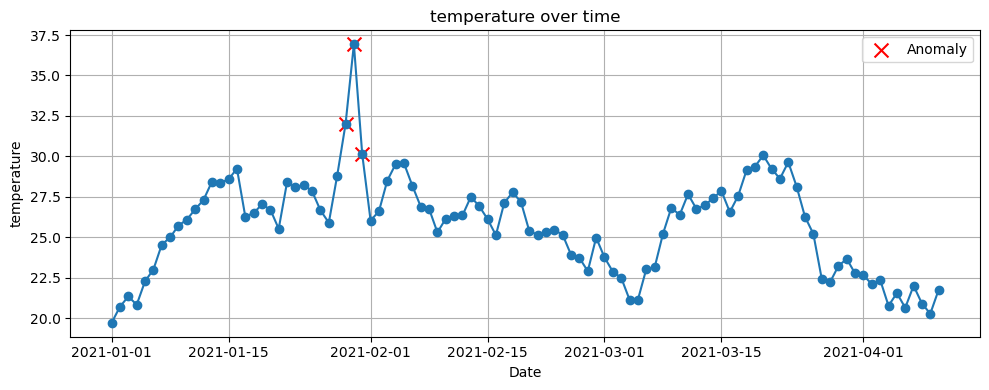

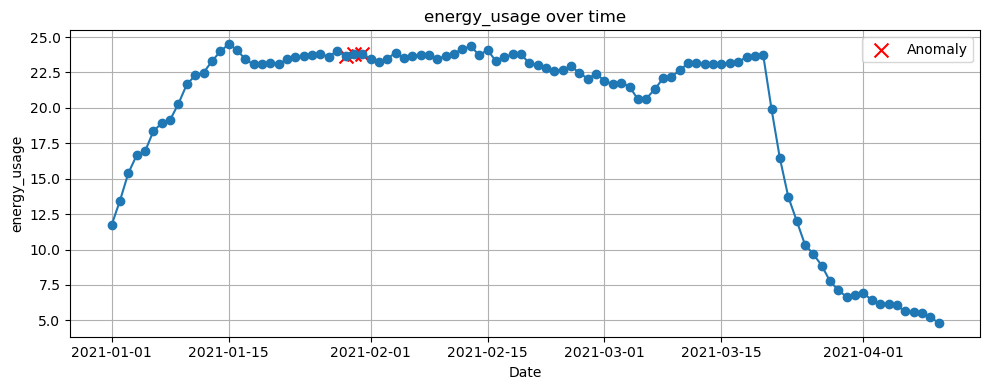

In [158]:
plot_features(df=df2122, y=y2122, start_day=1, start_year=2021, end_day=100, end_year=2021, features=["temperature", "energy_usage"])

### Statistics about the anomalies

In [159]:
print_summary(y2122)

Dataset Summary:
Total instances:         730
Normal instances (1):    712
Anomalous instances (-1): 18
Anomaly ratio:           2.466%


# Part 1: Anomaly detection
## <span style="color: red; font-weight: 700;">Your answers should start here!</span>

Use the provided functions to help you, if you want to code your own plotting functions, feel free to do so, but make sure the metrics calculation is correct!

### a) Data Transformation

In [160]:
from sklearn.preprocessing import OrdinalEncoder
import numpy as np

df2122Transformed = df2122.copy()

# 2: Sin/Cos mapping for day_of_year
# The sin, cos transform maps the periodic value to a unit circle, mod(max(column) + 1) - assuming the column is zero-numbered.
# this is because sin(0) == sin(2*pi)
sin_cos_transform(dataFrame=df2122Transformed, columnName='day_of_year')


# 1: Map season to integer
season_mapping = {'summer' : 0, 'autumn': 1, 'winter': 2, 'spring': 3}
df2122Transformed['season_encoded'] = df2122Transformed['season'].map(season_mapping)
sin_cos_transform(dataFrame=df2122Transformed, columnName='season_encoded')

# Remove season, season_encoded - makes the data too sparse.
# df2122Transformed.drop(columns=['season', 'season_encoded', 'season_encoded_cos', 'season_encoded_sin'], inplace=True)

# Remove day_of_year
df2122Transformed.drop(columns=['day_of_year'], inplace=True)

df2122Transformed

,year,season,temperature,humidity,energy_usage,day_of_year_sin,day_of_year_cos,season_encoded,season_encoded_sin,season_encoded_cos
0,2021,summer,19.708638,78.625889,11.731837,1.721336e-02,0.999852,0,0.0,1.0
1,2021,summer,20.703554,78.350411,13.453957,3.442161e-02,0.999407,0,0.0,1.0
2,2021,summer,21.339178,82.736788,15.393096,5.161967e-02,0.998667,0,0.0,1.0
3,2021,summer,20.823304,79.921728,16.657684,6.880243e-02,0.997630,0,0.0,1.0
4,2021,summer,22.277698,80.406175,16.927320,8.596480e-02,0.996298,0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
725,2022,summer,24.648768,79.422802,18.579817,-6.880243e-02,0.997630,0,0.0,1.0
726,2022,summer,24.362897,80.541095,19.394421,-5.161967e-02,0.998667,0,0.0,1.0
727,2022,summer,24.730546,85.748327,20.060006,-3.442161e-02,0.999407,0,0.0,1.0
728,2022,summer,26.975549,81.506959,20.840548,-1.721336e-02,0.999852,0,0.0,1.0


### TODO

1. change day_of_year to sin/cos mapping DONE
2. change season to sin/cos mapping DONE
3. remove day_of_year and season DONE
4. implement isolation forest
5. implement local outlier factor (LOF)
6. Note: Don't be stupid with hyperparameters, be selective...
7. tune the hyperparameters - contamination/n.estimators
8. tune the hyperparameters - contamination/n.neighbors

## b) Isolation Forest and LOF

### Isolation Forest

| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| isolation forest | 1.000 | 0.053 | 0.101 | 18 | 0 | 320 |


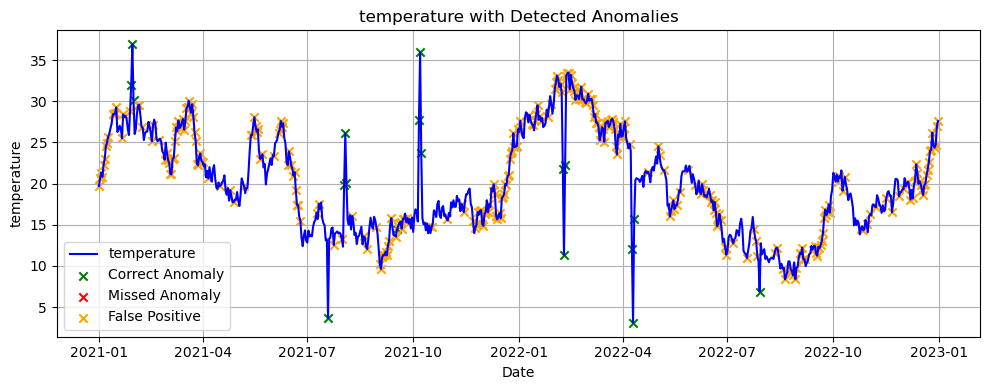

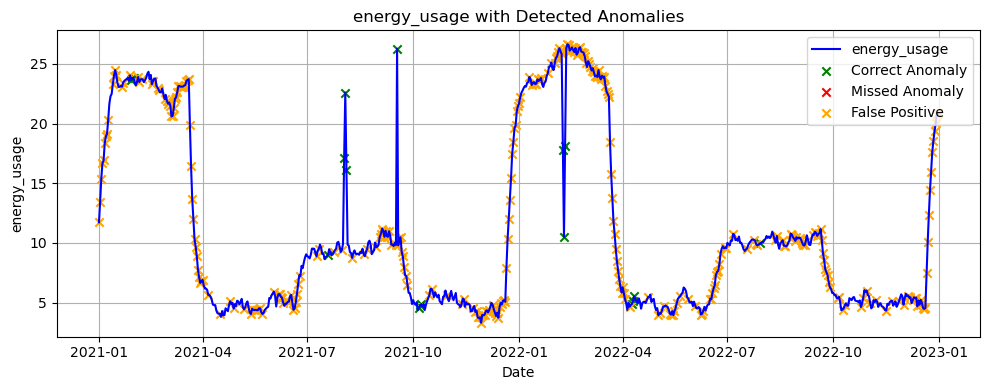

In [161]:
from sklearn.ensemble import IsolationForest

dfiso = df2122Transformed.drop(columns=['season', 'season_encoded'])
isolation_forest = IsolationForest(random_state=random_seed)
isolation_forest.fit(dfiso)
if_labels = isolation_forest.predict(dfiso)

if_table = Table()
evaluate_predictions(y_true=y2122, y_pred=if_labels, model_name="isolation forest", header=True, table=if_table)

if_table.report()

plot_detection(df=df2122, y_true=y2122, y_pred=if_labels, start_day=1, start_year=2021, end_day=365, end_year=2022, feature="temperature")

plot_detection(df=df2122, y_true=y2122, y_pred=if_labels, start_day=1, start_year=2021, end_day=365, end_year=2022, feature="energy_usage")



### LOF - Local Outlier Factor

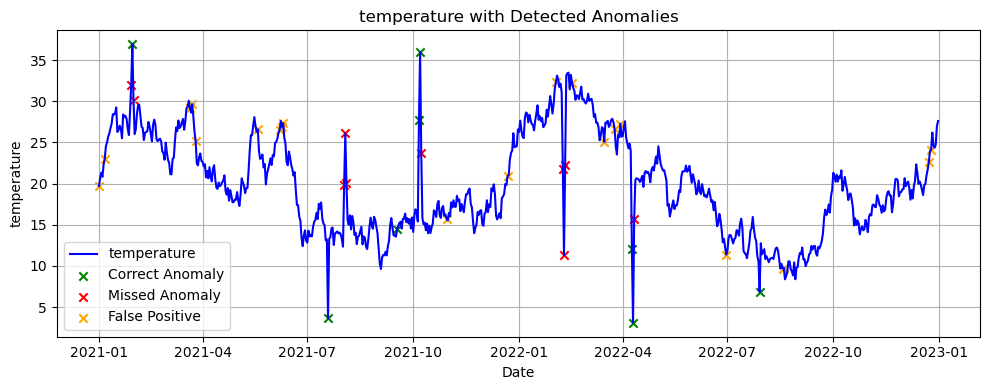

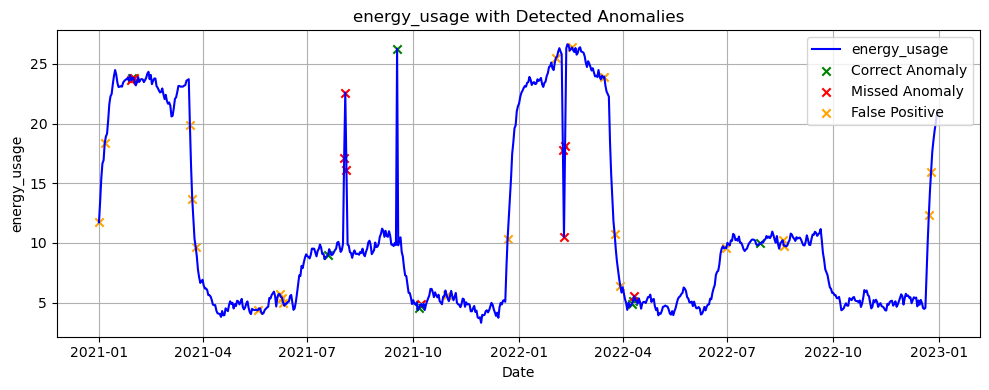

| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| local outlier factor | 0.444 | 0.276 | 0.340 | 8 | 10 | 21 |


In [162]:
from sklearn.neighbors import LocalOutlierFactor

dflof = df2122Transformed.drop(columns=['season', 'season_encoded'])
local_outlier_factor = LocalOutlierFactor()
lof_labels = local_outlier_factor.fit_predict(dflof)


plot_detection(df=df2122, y_true=y2122, y_pred=lof_labels, start_day=1, start_year=2021, end_day=365, end_year=2022, feature="temperature")
plot_detection(df=df2122, y_true=y2122, y_pred=lof_labels, start_day=1, start_year=2021, end_day=365, end_year=2022, feature="energy_usage")

lof_table = Table()
evaluate_predictions(y_true=y2122, y_pred=lof_labels, model_name="local outlier factor", header=True, table=lof_table)

lof_table.report()


### Answers

#### Which model had higher recall? Which had higher precision?

Isolation Forest had higher recall, Local Outlier Factor had higher precision. However, Isolation Forest had high recall because it had terrible precision, recording 190 false positives.

#### What do these differences suggest about how each algorithm works?

Isolation Forest is trying to determine if a value is separable from its peers by measuring how deep into a decision tree the values are bucketed. Local Outlier Factor is measuring how similar values are in the region around a point.

Local Outlier Factor is comparing a measurement with other nearby values, allowing it to detect the anomalies where the data changes rapidly.

#### In which situations would one be preferred over the other?

Isolation Forest will work best when there is a large number of values, and multiple examples for each range. For example, "year", with only two values ensures all trees using that feature are shallow - hindering the performance. Additionally, since it is (by default) considering a single feature per tree, it cannot detect problems where a values range varies with another value - it will only find globally extreme values.

Local Outlier Factor will work best when the distances between elements is Euclidean. If distance in some dimensions is different to others, then normal variation in that dimension may overwhelm the anomalous value. It is possible for LOF to "boil the frog", where the value changes over time slow enough that they aren't anomalies.

## c) Hyperparameter tuning


6. Note: Don't be stupid with hyperparameters, be selective...
7. tune the hyperparameters - contamination/n.estimators
8. tune the hyperparameters - contamination/n.neighbors

From looking at the original data, there are 730 rows. From a visual inspection of the graphs, I see 17 anomalies. The test data shows 18, but I'm going to pretend to not have that data.

Therefore, contamination = 17/230 = 0.0739.

### Isolation Forest

In [163]:
from sklearn.ensemble import IsolationForest
# Dropping the additional columns had _minimal_ effect until it got to "auto". It caused problems once we started tuning.
# dfiso = df2122Transformed.drop(columns=['season', 'season_encoded', 'year', 'season_encoded_cos', 'season_encoded_sin'])
dfiso = df2122Transformed.drop(columns=['season', 'season_encoded'])

iso_table = start_table()
for contamination in (0.01, 0.03, 0.05, 0.0739, 0.08, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 'auto') :
    isolation_forest = IsolationForest(random_state=random_seed, contamination=contamination)
    if_labels = isolation_forest.fit_predict(dfiso)
    evaluate_predictions(y_true=y2122, y_pred=if_labels, model_name=f"c={contamination}", header=False, table=iso_table)
iso_table.report()

iso_table = start_table()
for n_estimators in (5, 10, 30, 50, 100, 200, 300, 400, 500) :
    isolation_forest = IsolationForest(random_state=random_seed, n_estimators=n_estimators)
    if_labels = isolation_forest.fit_predict(dfiso)
    evaluate_predictions(y_true=y2122, y_pred=if_labels, model_name=f"n={n_estimators}", header=False, table=iso_table)
iso_table.report()

iso_table = start_table()
for contamination in (0.01, 0.03, 0.05, 0.07, 0.0739, 0.08, 0.09, 0.1, 0.15, 0.2, 'auto') :
    for n_estimators in (5, 10, 30, 50, 100, 200, 300, 400, 500) :
        isolation_forest = IsolationForest(random_state=random_seed, n_estimators=n_estimators, contamination=contamination)
        if_labels = isolation_forest.fit_predict(dfiso)
        evaluate_predictions(y_true=y2122, y_pred=if_labels, model_name=f"({contamination}, {n_estimators})", header=False, table=iso_table)
iso_table.report()


| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| c=0.01 | 0.167 | 0.375 | 0.231 | 3 | 15 | 5 |
| c=0.03 | 0.222 | 0.182 | 0.200 | 4 | 14 | 18 |
| c=0.05 | 0.333 | 0.162 | 0.218 | 6 | 12 | 31 |
| c=0.0739 | 0.389 | 0.130 | 0.194 | 7 | 11 | 47 |
| c=0.08 | 0.500 | 0.153 | 0.234 | 9 | 9 | 50 |
| c=0.1 | 0.556 | 0.137 | 0.220 | 10 | 8 | 63 |
| c=0.15 | 0.667 | 0.109 | 0.188 | 12 | 6 | 98 |
| c=0.2 | 0.667 | 0.082 | 0.146 | 12 | 6 | 134 |
| c=0.25 | 0.722 | 0.071 | 0.129 | 13 | 5 | 170 |
| c=0.3 | 0.778 | 0.064 | 0.118 | 14 | 4 | 205 |
| c=0.35 | 0.944 | 0.066 | 0.124 | 17 | 1 | 239 |
| c=0.4 | 1.000 | 0.062 | 0.116 | 18 | 0 | 274 |
| c=0.45 | 1.000 | 0.055 | 0.104 | 18 | 0 | 311 |
| c=0.5 | 1.000 | 0.049 | 0.094 | 18 | 0 | 347 |
| c=auto | 1.000 | 0.053 | 0.101 | 18 | 0 | 320 |


| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| n=5 | 1.000 | 0.042 | 0.080 | 18 | 0 | 412 |
| n=10 | 0.944 | 0.043 | 0.082 | 17 | 1 | 382 |
| n=30 | 0.944 | 0.053 | 0.100 | 17 | 1 | 305 |
| n=50 | 1.000 | 0.050 | 0.096 | 18 | 0 | 339 |
| n=100 | 1.000 | 0.053 | 0.101 | 18 | 0 | 320 |
| n=200 | 1.000 | 0.052 | 0.098 | 18 | 0 | 330 |
| n=300 | 1.000 | 0.053 | 0.101 | 18 | 0 | 321 |
| n=400 | 1.000 | 0.051 | 0.097 | 18 | 0 | 335 |
| n=500 | 1.000 | 0.050 | 0.095 | 18 | 0 | 341 |


| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| (0.01, 5) | 0.000 | 0.000 | 0.000 | 0 | 18 | 8 |
| (0.01, 10) | 0.056 | 0.125 | 0.077 | 1 | 17 | 7 |
| (0.01, 30) | 0.056 | 0.125 | 0.077 | 1 | 17 | 7 |
| (0.01, 50) | 0.167 | 0.375 | 0.231 | 3 | 15 | 5 |
| (0.01, 100) | 0.167 | 0.375 | 0.231 | 3 | 15 | 5 |
| (0.01, 200) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.01, 300) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.01, 400) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.01, 500) | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| (0.03, 5) | 0.111 | 0.091 | 0.100 | 2 | 16 | 20 |
| (0.03, 10) | 0.111 | 0.091 | 0.100 | 2 | 16 | 20 |
| (0.03, 30) | 0.222 | 0.182 | 0.200 | 4 | 14 | 18 |
| (0.03, 50) | 0.278 | 0.227 | 0.250 | 5 | 13 | 17 |
| (0.03, 100) | 0.222 | 0.182 | 0.200 | 4 | 14 | 18 |
| (0.03, 200) | 0.278 | 0.227 | 0.250 | 5 | 13 | 17 |
| (0.03, 300) | 0.333 | 0.273 | 0.300 | 6 | 12 | 16 |
| (0.03, 400) | 0.333 | 0.273 | 0.300 | 6 | 12 | 16 |
| (0.03, 500) | 0.333 | 0.273 | 0.300 | 6 | 12 | 16 |
| (0.05, 5) | 0.278 | 0.135 | 0.182 | 5 | 13 | 32 |
| (0.05, 10) | 0.222 | 0.108 | 0.145 | 4 | 14 | 33 |
| (0.05, 30) | 0.333 | 0.162 | 0.218 | 6 | 12 | 31 |
| (0.05, 50) | 0.278 | 0.135 | 0.182 | 5 | 13 | 32 |
| (0.05, 100) | 0.333 | 0.162 | 0.218 | 6 | 12 | 31 |
| (0.05, 200) | 0.389 | 0.189 | 0.255 | 7 | 11 | 30 |
| (0.05, 300) | 0.389 | 0.189 | 0.255 | 7 | 11 | 30 |
| (0.05, 400) | 0.389 | 0.189 | 0.255 | 7 | 11 | 30 |
| (0.05, 500) | 0.444 | 0.216 | 0.291 | 8 | 10 | 29 |
| (0.07, 5) | 0.389 | 0.137 | 0.203 | 7 | 11 | 44 |
| (0.07, 10) | 0.222 | 0.077 | 0.114 | 4 | 14 | 48 |
| (0.07, 30) | 0.333 | 0.115 | 0.171 | 6 | 12 | 46 |
| (0.07, 50) | 0.333 | 0.115 | 0.171 | 6 | 12 | 46 |
| (0.07, 100) | 0.389 | 0.135 | 0.200 | 7 | 11 | 45 |
| (0.07, 200) | 0.611 | 0.212 | 0.314 | 11 | 7 | 41 |
| (0.07, 300) | 0.611 | 0.212 | 0.314 | 11 | 7 | 41 |
| (0.07, 400) | 0.667 | 0.231 | 0.343 | 12 | 6 | 40 |
| (0.07, 500) | 0.667 | 0.231 | 0.343 | 12 | 6 | 40 |
| (0.0739, 5) | 0.389 | 0.132 | 0.197 | 7 | 11 | 46 |
| (0.0739, 10) | 0.222 | 0.074 | 0.111 | 4 | 14 | 50 |
| (0.0739, 30) | 0.333 | 0.111 | 0.167 | 6 | 12 | 48 |
| (0.0739, 50) | 0.333 | 0.111 | 0.167 | 6 | 12 | 48 |
| (0.0739, 100) | 0.389 | 0.130 | 0.194 | 7 | 11 | 47 |
| (0.0739, 200) | 0.611 | 0.204 | 0.306 | 11 | 7 | 43 |
| (0.0739, 300) | 0.611 | 0.204 | 0.306 | 11 | 7 | 43 |
| (0.0739, 400) | 0.667 | 0.222 | 0.333 | 12 | 6 | 42 |
| (0.0739, 500) | 0.667 | 0.222 | 0.333 | 12 | 6 | 42 |
| (0.08, 5) | 0.444 | 0.140 | 0.213 | 8 | 10 | 49 |
| (0.08, 10) | 0.222 | 0.068 | 0.104 | 4 | 14 | 55 |
| (0.08, 30) | 0.333 | 0.102 | 0.156 | 6 | 12 | 53 |
| (0.08, 50) | 0.389 | 0.119 | 0.182 | 7 | 11 | 52 |
| (0.08, 100) | 0.500 | 0.153 | 0.234 | 9 | 9 | 50 |
| (0.08, 200) | 0.611 | 0.186 | 0.286 | 11 | 7 | 48 |
| (0.08, 300) | 0.611 | 0.186 | 0.286 | 11 | 7 | 48 |
| (0.08, 400) | 0.667 | 0.203 | 0.312 | 12 | 6 | 47 |
| (0.08, 500) | 0.667 | 0.203 | 0.312 | 12 | 6 | 47 |
| (0.09, 5) | 0.556 | 0.152 | 0.238 | 10 | 8 | 56 |
| (0.09, 10) | 0.222 | 0.061 | 0.095 | 4 | 14 | 62 |
| (0.09, 30) | 0.333 | 0.091 | 0.143 | 6 | 12 | 60 |
| (0.09, 50) | 0.444 | 0.121 | 0.190 | 8 | 10 | 58 |
| (0.09, 100) | 0.556 | 0.152 | 0.238 | 10 | 8 | 56 |
| (0.09, 200) | 0.611 | 0.167 | 0.262 | 11 | 7 | 55 |
| (0.09, 300) | 0.667 | 0.182 | 0.286 | 12 | 6 | 54 |
| (0.09, 400) | 0.667 | 0.182 | 0.286 | 12 | 6 | 54 |
| (0.09, 500) | 0.667 | 0.182 | 0.286 | 12 | 6 | 54 |
| (0.1, 5) | 0.556 | 0.137 | 0.220 | 10 | 8 | 63 |
| (0.1, 10) | 0.222 | 0.055 | 0.088 | 4 | 14 | 69 |
| (0.1, 30) | 0.444 | 0.110 | 0.176 | 8 | 10 | 65 |
| (0.1, 50) | 0.556 | 0.137 | 0.220 | 10 | 8 | 63 |
| (0.1, 100) | 0.556 | 0.137 | 0.220 | 10 | 8 | 63 |
| (0.1, 200) | 0.667 | 0.164 | 0.264 | 12 | 6 | 61 |
| (0.1, 300) | 0.667 | 0.164 | 0.264 | 12 | 6 | 61 |
| (0.1, 400) | 0.667 | 0.164 | 0.264 | 12 | 6 | 61 |
| (0.1, 500) | 0.667 | 0.164 | 0.264 | 12 | 6 | 61 |
| (0.15, 5) | 0.667 | 0.109 | 0.188 | 12 | 6 | 98 |
| (0.15, 10) | 0.444 | 0.073 | 0.125 | 8 | 10 | 102 |
| (0.15, 30) | 0.667 | 0.109 | 0.188 | 12 | 6 | 98 |
| (0.15, 50) | 0.722 | 0.118 | 0.203 | 13 | 5 | 97 |
| (0.15, 100) | 0.667 | 0.109 | 0.188 | 12 | 6 | 98 |
| (0.15, 200) | 0.667 | 0.109 | 0.188 | 12 | 6 | 98 |
| (0.15, 300) | 0.667 | 0.109 | 0.188 | 12 | 6 | 98 |
| (0.15, 400) | 0.667 | 0.109 | 0.188 | 12 | 6 | 98 |
| (0.15, 500) | 0.667 | 0.109 | 0.188 | 12 | 6 | 98 |
| (0.2, 5) | 0.722 | 0.089 | 0.159 | 13 | 5 | 133 |
| (0.2, 10) | 0.667 | 0.082 | 0.146 | 12 | 6 | 134 |
| (0.2, 30) | 0.778 | 0.096 | 0.171 | 14 | 4 | 132 |
| (0.2, 50) | 0.722 | 0.089 | 0.159 | 13 | 5 | 133 |
| (0.2, 100) | 0.667 | 0.082 | 0.146 | 12 | 6 | 134 |
| (0.2, 200) | 0.667 | 0.082 | 0.146 | 12 | 6 | 134 |
| (0.2, 300) | 0.667 | 0.082 | 0.146 | 12 | 6 | 134 |
| (0.2, 400) | 0.667 | 0.082 | 0.146 | 12 | 6 | 134 |
| (0.2, 500) | 0.667 | 0.082 | 0.146 | 12 | 6 | 134 |
| (auto, 5) | 1.000 | 0.042 | 0.080 | 18 | 0 | 412 |
| (auto, 10) | 0.944 | 0.043 | 0.082 | 17 | 1 | 382 |
| (auto, 30) | 0.944 | 0.053 | 0.100 | 17 | 1 | 305 |
| (auto, 50) | 1.000 | 0.050 | 0.096 | 18 | 0 | 339 |
| (auto, 100) | 1.000 | 0.053 | 0.101 | 18 | 0 | 320 |
| (auto, 200) | 1.000 | 0.052 | 0.098 | 18 | 0 | 330 |
| (auto, 300) | 1.000 | 0.053 | 0.101 | 18 | 0 | 321 |
| (auto, 400) | 1.000 | 0.051 | 0.097 | 18 | 0 | 335 |
| (auto, 500) | 1.000 | 0.050 | 0.095 | 18 | 0 | 341 |


In [164]:
from sklearn.ensemble import IsolationForest

dfiso = df2122Transformed.drop(columns=['season', 'season_encoded'])

report("**Post Search Hyperparameters**")
iso_table = start_table()

contamination = 0.07
n_estimators = 400
isolation_forest = IsolationForest(random_state=random_seed, contamination=contamination, n_estimators=n_estimators)
if_labels = isolation_forest.fit_predict(dfiso)
evaluate_predictions(y_true=y2122, y_pred=if_labels, model_name=f"({contamination}, {n_estimators})", header=False, table=iso_table)

iso_table.report()


**Post Search Hyperparameters**

| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| (0.07, 400) | 0.667 | 0.231 | 0.343 | 12 | 6 | 40 |


### Local Outlier Factor

In [167]:
from sklearn.neighbors import LocalOutlierFactor

dflof = df2122Transformed.drop(columns=['season', 'season_encoded'])

lof_table = start_table()
for contamination in (0.01, 0.03, 0.05, 0.0739, 0.08, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 'auto') :
    local_outlier_factor = LocalOutlierFactor(contamination=contamination)
    lof_labels = local_outlier_factor.fit_predict(dflof)
    evaluate_predictions(y_true=y2122, y_pred=lof_labels, model_name=f"c={contamination}", header=False, table=lof_table)
lof_table.report()

lof_table = start_table()
for n_neighbours in (5, 10, 20, 30, 40, 50, 60, 70) :
    local_outlier_factor = LocalOutlierFactor(n_neighbors=n_neighbours)
    lof_labels = local_outlier_factor.fit_predict(dflof)
    evaluate_predictions(y_true=y2122, y_pred=lof_labels, model_name=f"n={n_neighbours}", header=False, table=lof_table)
lof_table.report()



| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| c=0.01 | 0.222 | 0.500 | 0.308 | 4 | 14 | 4 |
| c=0.03 | 0.333 | 0.273 | 0.300 | 6 | 12 | 16 |
| c=0.05 | 0.500 | 0.243 | 0.327 | 9 | 9 | 28 |
| c=0.0739 | 0.500 | 0.167 | 0.250 | 9 | 9 | 45 |
| c=0.08 | 0.500 | 0.153 | 0.234 | 9 | 9 | 50 |
| c=0.1 | 0.556 | 0.137 | 0.220 | 10 | 8 | 63 |
| c=0.15 | 0.611 | 0.100 | 0.172 | 11 | 7 | 99 |
| c=0.2 | 0.778 | 0.096 | 0.171 | 14 | 4 | 132 |
| c=0.25 | 0.889 | 0.087 | 0.159 | 16 | 2 | 167 |
| c=0.3 | 1.000 | 0.082 | 0.152 | 18 | 0 | 201 |
| c=0.35 | 1.000 | 0.070 | 0.131 | 18 | 0 | 238 |
| c=0.4 | 1.000 | 0.062 | 0.116 | 18 | 0 | 274 |
| c=0.45 | 1.000 | 0.055 | 0.104 | 18 | 0 | 311 |
| c=0.5 | 1.000 | 0.049 | 0.094 | 18 | 0 | 347 |
| c=auto | 0.444 | 0.276 | 0.340 | 8 | 10 | 21 |


| Model | Recall | Precision | F1 Score | Correct | Missed | False Positives |
| --- | --- | --- | --- | --- | --- | --- |
| n=5 | 0.556 | 0.345 | 0.426 | 10 | 8 | 19 |
| n=10 | 0.500 | 0.290 | 0.367 | 9 | 9 | 22 |
| n=20 | 0.444 | 0.276 | 0.340 | 8 | 10 | 21 |
| n=30 | 0.389 | 0.269 | 0.318 | 7 | 11 | 19 |
| n=40 | 0.444 | 0.286 | 0.348 | 8 | 10 | 20 |
| n=50 | 0.444 | 0.296 | 0.356 | 8 | 10 | 19 |
| n=60 | 0.444 | 0.308 | 0.364 | 8 | 10 | 18 |
| n=70 | 0.444 | 0.308 | 0.364 | 8 | 10 | 18 |


## d) Model Selection and Analysis

## e) (AIML420 mandatory)  Exploring Alternative Approaches